# PROYECTO EBA
## Flujo Completo
1. EXPLORACIÓN PREELIMINAR (Formatos / errores a grosso modo)
    - Abrir los ficheros
    - Comprobar formatos de columnas y filas
        - Detectar errores

2. LIMPIEZA GENERAL
    - Formato de Columnas
    - Columnas innecesarias
    - Formato de valores
    - Duplicados

3. LIMPIEZA ESPECIFICA
    - Tipo de los datos
    - Valores únicos por columna (¿errores?)
    - Gestion de nulos

4. TRANSFORMACIONES
    - Unificación de dataframes (en caso de ser necesario)
    - Ceación de nuevas columnas (agrupaciones, calculos, etc)

5. EXPLORACIÓN EN PROFUNDIDAD
    - Análisis descriptivo
        - Métricas generales
        - Explorar relación entre variables
    > Primeros gráficos

6. ANÁLISIS
    - Generación de hipótesis
    - Comprobación de hipótesis
    - Crear informe detallado
        - Objetivo
        - Hipótesis
        - Resultados con datos
        - Conclusies

## EXPLORACIÓN PREELIMINAR

### Apertura de ficheros (conversión a dataframe)
En primer lugar necesitamos poder acceder a la información de los ficheros, que nos vienen dados en dos formatos diferentres, como fichero CSV y como EXCEL.

En primer lugar definimos una función para atomatizar la apertura de ficheros de cualquier de los tipos, por lo que debe ser capaz de:
- Identificar el tipo de ficher (excel o csv)
- Transformarlo a dataframe (usando pandas)

> La función se crea dentro de la carpeta **infraestructure** (infraestrutura), en el archivo **file_utils.py** (utilidades de ficheros).

Una vez creada la función podemos importarla como el resto de librerías:

In [1]:
# Importamos las librerías necesarias para abrir nuestros data_frames
import pandas as pd
from infraestructure.file_utils import file_to_dataframe

In [2]:
# Configuramos para que se muestren todas las columnas siempre de los dataframes
pd.set_option('display.max_columns', None)

In [3]:
# Generamos los dataframes para empezar a explorarlos
df_bank = file_to_dataframe('bank-additional.csv')
df_bank.head(2)

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097


In [4]:
# Queremos ver todos los nombres de columnas de este dataframe
df_bank.columns

Index(['Unnamed: 0', 'age', 'job', 'marital', 'education', 'default',
       'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude',
       'longitude', 'id_'],
      dtype='object')

In [5]:
df_customer_12 = file_to_dataframe("customer-details.xlsx", "2012")
df_customer_13 = file_to_dataframe("customer-details.xlsx", "2013")
df_customer_14 = file_to_dataframe("customer-details.xlsx", "2014")

Path: C:\Users\Usuario\OneDrive\Documentos\GitHub\DataProyect_EDA_Python\files\input\customer-details.xlsx
Path: C:\Users\Usuario\OneDrive\Documentos\GitHub\DataProyect_EDA_Python\files\input\customer-details.xlsx
Path: C:\Users\Usuario\OneDrive\Documentos\GitHub\DataProyect_EDA_Python\files\input\customer-details.xlsx


In [6]:
df_customer_12.head(2)

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097


In [7]:
df_customer_13.head(2)

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be
1,1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479


In [8]:
df_customer_14.head(2)

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,168812,1,1,2014-06-10,27,4d6c811c-0f24-4a73-b374-2ebd1f80d46e
1,1,108615,2,1,2014-04-05,24,eef0f24f-cbdb-4c67-b371-09d7bc59695e


### Comprobar columnas y filas

#### Observaciones iniciales
- Los nombres de las columnas de los ficheros no tienen un formato unificado
- Todas tienen una columna "Unnamed: 0" que es el index --> innecesaria 

#### Pasos de limpieza iniciales (columnas)
- Unificar el formato de los nombres de las columnas:
    - Nombres en mayúsculas
    - Sin espacios antes o despues
    - Eliminar la columna "Unnamed: 0" 

> Creamos una función de limpieza general en domain/formatting_utils.py

In [9]:
# Importamos la función creada para usarla en nustros dataframes
from infraestructure.formatting_utils import column_names_formatting

In [10]:
# Creamos una lista de dataframes para trabajar con ellos de manera mas eficiente (sin tener que ir uno a uno)
dataframe_list = [df_bank, df_customer_12, df_customer_13, df_customer_14]

# Primero eliminamos de todos la columna que nos sobra "Unnamed: 0"
df_bank, df_customer_12, df_customer_13, df_customer_14 = map(lambda df: df.drop(columns=["Unnamed: 0"], errors="ignore"), dataframe_list)

# Actualizamos la lista de dataframes con la versión actualizada
dataframe_list = [df_bank, df_customer_12, df_customer_13, df_customer_14]

# Y pasamos nuestra función de limpieza de nombres
df_bank, df_customer_12, df_customer_13, df_customer_14 = map(column_names_formatting, dataframe_list)

Y comprobamos que nuestros cambios se han realizado correctamente:

In [11]:
# Imprimimos los nombres de las columnas para comprobar que en efecto se han formateado corretamente
for df in dataframe_list:
    print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_'],
      dtype='object')
Index(['Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth',
       'ID'],
      dtype='object')
Index(['Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth',
       'ID'],
      dtype='object')
Index(['Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth',
       'ID'],
      dtype='object')


### Análisis inicial de cada dataframe
Una vez realizado el ajuste básico del formato de columnas pasamos a analizar con algo mas de detalle los aspectos básicos de cada uno de los dataframes.

Necesitamos explorar:
- Tipos de datos de cada columna
- Si hay duplicados
- Si hay nulos y en qué porcentaje para cada columna
- En las columnas categóricas:
    - Valores únicos existentes
        - Detectar posibles errores

#### Duplicados
Vamos a empezar por la gestion de valores duplicados que es la más sencilla porque tenemos un método específico para gestionarlos:
```
drop_duplicates()
```

In [12]:
# Volvemos a generar nuestra lista de dataframes
df_names = ["df_bank", "df_customer_12", "df_customer_13", "df_customer_14"]
dataframe_list = [df_bank, df_customer_12, df_customer_13, df_customer_14]

In [13]:
# Y contamos el numero de duplicados por dataframe
for (name, df) in zip(df_names, dataframe_list):
    print(f'{name} - {df.duplicated().sum()} duplicates')

df_bank - 0 duplicates
df_customer_12 - 0 duplicates
df_customer_13 - 0 duplicates
df_customer_14 - 0 duplicates


Como no tenemos duplicados, no es necesario hacer ningun paso adicional. Pero en caso de haberlos, bastaría con utilizar la siguiente línea de código:
```py
df_bank, df_customer_12, df_customer_13, df_customer_14 = map(lambda df: df.drop_duplicates(),dataframe_list)
```

#### Tipos de datos por df y columna
Necesitamos empezar a mirar con más detalle la organización interna de cada uno de los dataframes. Para tener una idea general de la cantidad de datos, tipo de dato de cada columna, numero de nulos, etc. contamos con el métido **info()**.

##### Análisis dataframe de campaña de márketing (df_bank)

In [14]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AGE           37880 non-null  float64
 1   JOB           42655 non-null  object 
 2   MARITAL       42915 non-null  object 
 3   EDUCATION     41193 non-null  object 
 4   DEFAULT       34019 non-null  float64
 5   HOUSING       41974 non-null  float64
 6   LOAN          41974 non-null  float64
 7   CONTACT       43000 non-null  object 
 8   DURATION      43000 non-null  int64  
 9   CAMPAIGN      43000 non-null  int64  
 10  PDAYS         43000 non-null  int64  
 11  PREVIOUS      43000 non-null  int64  
 12  POUTCOME      43000 non-null  object 
 13  EMPVARRATE    43000 non-null  float64
 14  CONSPRICEIDX  42529 non-null  object 
 15  CONSCONFIDX   43000 non-null  object 
 16  EURIBOR3M     33744 non-null  object 
 17  NREMPLOYED    43000 non-null  object 
 18  Y             43000 non-nu

El método **info()** nos da una idea general de que:
- Hay 43000 registros (filas) en total
- Hay columnas con valores nulos
- Reparto de tipos de columnas:
    - Decimales (float64): 7 columnas
    - Enteros (int54): 4 columnas
    - Categoricos (object): 12 columnas

Pero queremos mirar en mas detalle, por lo que vamos a crear funciones que nos permitan extraer información más a detalle:
- Porcentaje de nulos por columna
- Valores únicos dentro de las columnas categóricas

Este proceso, que nos servirá para la valoración de los demás dataframes tambien, nos será útil para decidir:
- Si alguna columna requiere un cambio de tipo de dato
- Si alguna columna categórica requiere de una limpieza personalziada (ej. valores con errores)
- Mejor manera de gestionar los valores nulos
- Valorar creación de nuevas columnas que aporten información complementaria

##### Función info extendida
En eda/infraestructure/explore_utils creamos una función llamada **info_dataframe** que nos dará información adicional sobre los datos del dataframe:

In [15]:
# Importamos el fichero con la funcion
from infraestructure.explore_utils import info_dataframe

In [16]:
df_info_bank = info_dataframe(df_bank)
df_info_bank

,COLUMN_NAME,NON_NULL_COUNT,NULL_COUNT,NULL_PERCENT,DTYPE
0,AGE,37880,5120,11.91,float64
1,JOB,42655,345,0.80,object
2,MARITAL,42915,85,0.20,object
3,EDUCATION,41193,1807,4.20,object
4,DEFAULT,34019,8981,20.89,float64
5,HOUSING,41974,1026,2.39,float64
6,LOAN,41974,1026,2.39,float64
7,CONTACT,43000,0,0.00,object
8,DURATION,43000,0,0.00,int64
9,CAMPAIGN,43000,0,0.00,int64


In [17]:
for value,ty in zip(df_info_bank["COLUMN_NAME" ],df_info_bank["DTYPE" ]):
    print(f'{value} ---> {ty}')

AGE ---> float64
JOB ---> object
MARITAL ---> object
EDUCATION ---> object
DEFAULT ---> float64
HOUSING ---> float64
LOAN ---> float64
CONTACT ---> object
DURATION ---> int64
CAMPAIGN ---> int64
PDAYS ---> int64
PREVIOUS ---> int64
POUTCOME ---> object
EMPVARRATE ---> float64
CONSPRICEIDX ---> object
CONSCONFIDX ---> object
EURIBOR3M ---> object
NREMPLOYED ---> object
Y ---> object
DATE ---> object
LATITUDE ---> float64
LONGITUDE ---> float64
ID ---> object


Al revisar los tipos de datos, dectamos que hay algunas columnas con un tipo de dato incorrecto: Destacan varios valores tipo "object" que deberían ser formato "floar" o al menos numérico.

Los revisamos en mayor detalle:

In [18]:
# Aislamos las columnas con valores "object"

df_info_bank.where(df_info_bank['DTYPE'] == "object")

,COLUMN_NAME,NON_NULL_COUNT,NULL_COUNT,NULL_PERCENT,DTYPE
0,NaN,NaN,NaN,NaN,NaN
1,JOB,42655.0,345.0,0.80,object
2,MARITAL,42915.0,85.0,0.20,object
3,EDUCATION,41193.0,1807.0,4.20,object
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,CONTACT,43000.0,0.0,0.00,object
8,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN


In [19]:
df_filtered = df_info_bank[df_info_bank["DTYPE"] == "object"]
df_filtered

,COLUMN_NAME,NON_NULL_COUNT,NULL_COUNT,NULL_PERCENT,DTYPE
1,JOB,42655,345,0.80,object
2,MARITAL,42915,85,0.20,object
3,EDUCATION,41193,1807,4.20,object
7,CONTACT,43000,0,0.00,object
12,POUTCOME,43000,0,0.00,object
14,CONSPRICEIDX,42529,471,1.10,object
15,CONSCONFIDX,43000,0,0.00,object
16,EURIBOR3M,33744,9256,21.53,object
17,NREMPLOYED,43000,0,0.00,object
18,Y,43000,0,0.00,object


In [20]:
bank_object_cols = [x for x in df_filtered["COLUMN_NAME"]]

In [21]:
df_bank_object = df_bank[bank_object_cols]
df_bank_object.sample(5)

,JOB,MARITAL,EDUCATION,CONTACT,POUTCOME,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,Y,DATE,ID
42681,unemployed,MARRIED,high.school,cellular,FAILURE,"93,2",-42,NaN,"5195,8",no,23-septiembre-2016,072a3d62-8d4a-4857-847a-04a354204985
32657,technician,SINGLE,professional.course,cellular,FAILURE,"92,893","-46,2","1,299","5099,1",no,1-agosto-2015,316a9b6d-92e1-4f33-99b2-3020a7d84a35
13496,admin.,DIVORCED,university.degree,cellular,NONEXISTENT,"93,918","-42,7","4,963","5228,1",no,17-marzo-2017,88d98d97-d831-4e85-9c5c-80824161f425
40595,student,SINGLE,basic.9y,cellular,NONEXISTENT,"94,199","-37,5","0,879","4963,6",yes,21-marzo-2016,34909081-3421-4328-babf-f0a31c3df36b
32488,services,MARRIED,high.school,telephone,FAILURE,"92,893","-46,2","1,299","5099,1",no,25-diciembre-2015,6217ecc2-3eff-44ef-bde8-7381449cd900


In [22]:
df_bank_object.columns

Index(['JOB', 'MARITAL', 'EDUCATION', 'CONTACT', 'POUTCOME', 'CONSPRICEIDX',
       'CONSCONFIDX', 'EURIBOR3M', 'NREMPLOYED', 'Y', 'DATE', 'ID'],
      dtype='object')

Detectamos que el problema con las columnas  ['CONSPRICEIDX','CONSCONFIDX', 'EURIBOR3M', 'NREMPLOYED'] es que los decimales están como "," en vez de "." por lo que pandas no los entiende como valores numericos decimales (float) sino como cadenas de texto (strings o objects).

Así que el siguente paso es hacer un replace en las 4 columnas para después poder comvertirlas al tipo de dato correcto.

In [23]:
to_float_columns = ['CONSPRICEIDX','CONSCONFIDX', 'EURIBOR3M', 'NREMPLOYED']

In [24]:
# Uso .astype("string") porque quiero que los nulos sigan siendo leidos como nulos pero remplazar los strings por mi nuevo formato
df_bank[to_float_columns] = df_bank[to_float_columns].astype("string").apply(lambda x: x.str.replace(",",".").astype("Float64"))

In [25]:
# Y comprobamos que efectivamente hemos cambiado el tipo de dato

df_bank[to_float_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CONSPRICEIDX  42529 non-null  Float64
 1   CONSCONFIDX   43000 non-null  Float64
 2   EURIBOR3M     33744 non-null  Float64
 3   NREMPLOYED    43000 non-null  Float64
dtypes: Float64(4)
memory usage: 1.5 MB


Ahora vamos a continuar evaluando el resto de columnas tipo object para detectar mas posibles errores:

In [26]:
# Importamos una funcion específica para facilitar este proceso

from infraestructure.explore_utils import column_type_dataframe

In [27]:
# Actualizamos nuestor DF info y nuestro df_bank_object

df_bank_object, bank_object_cols = column_type_dataframe(df_bank, "object")

In [28]:
df_bank_object.sample(5)

,JOB,MARITAL,EDUCATION,CONTACT,POUTCOME,Y,DATE,ID
42250,services,SINGLE,professional.course,cellular,SUCCESS,yes,21-noviembre-2016,a1155525-ea34-4703-93bc-4a705a1a1272
11265,technician,MARRIED,university.degree,telephone,NONEXISTENT,no,19-marzo-2015,c1e2cfb4-dbff-4952-a1b0-4d88ae2b9e5b
8837,services,MARRIED,high.school,telephone,NONEXISTENT,no,25-agosto-2019,627f7d32-34a8-41cb-b6db-44d7dc680055
41378,blue-collar,MARRIED,NaN,telephone,NONEXISTENT,no,3-julio-2016,5f1bb70f-fb09-49ef-9359-e862d671fe3b
18031,services,SINGLE,basic.9y,cellular,NONEXISTENT,no,16-septiembre-2019,3d6f00a4-6a3b-4627-9f9f-990ee1078cdd


In [29]:
# Analizamos los valores unicos existentes en cada una de las columnas

for col in df_bank_object.columns:
    print(f'{col} --> {df_bank_object[col].unique()}\n')

JOB --> ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' nan 'entrepreneur' 'student']

MARITAL --> ['MARRIED' 'SINGLE' 'DIVORCED' nan]

EDUCATION --> ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course' nan
 'university.degree' 'illiterate']

CONTACT --> ['telephone' 'cellular']

POUTCOME --> ['NONEXISTENT' 'FAILURE' 'SUCCESS']

Y --> ['no' 'yes']

DATE --> ['2-agosto-2019' '14-septiembre-2016' '15-febrero-2019' ... '28-mayo-2016'
 '22-abril-2015' '7-marzo-2015']

ID --> ['089b39d8-e4d0-461b-87d4-814d71e0e079'
 'e9d37224-cb6f-4942-98d7-46672963d097'
 '3f9f49b5-e410-4948-bf6e-f9244f04918b' ...
 'cadadd4b-7ee5-4019-b13a-ca01bb67ca5b'
 '5f432048-d515-4bb5-9c94-62db451f88d4'
 '993bbbd6-4dbc-4a40-a408-f91f8462bee6']



Detectamos varias inconsistencias:
- No hay un formato uniforme: mayusculas o minusuculas, separación entre palabras
- La columna DATE debería ser formato fecha

Se realizarán los siguientes cambios:
1. Todos los valores estén en minuscula (para diferenciarlos de los nombres de columnas)
2. La separación entre palabras se realizará con con "-" en vez de "."
3. La columna DATE se convertirá a formato fecha

In [30]:
# Ajuste a minusculas y espacios. Uso .astype("string") porque quiero que los nulos sigan siendo leidos como nulos pero remplazar los strings por mi nuevo formato
df_bank[bank_object_cols] = (
    df_bank[bank_object_cols].astype("string").apply(lambda x: x.str.replace(".", "-").str.lower())
)

In [31]:
df_bank[bank_object_cols].sample(3)

,JOB,MARITAL,EDUCATION,CONTACT,POUTCOME,Y,DATE,ID
11079,services,married,<NA>,telephone,nonexistent,no,11-mayo-2017,833ccafc-e25f-4891-97b3-5b689dc2a625
27680,technician,married,professional-course,cellular,nonexistent,yes,8-noviembre-2015,23c99026-f068-4d57-9588-53f6cf2923c5
29965,blue-collar,married,basic-6y,cellular,nonexistent,no,14-julio-2019,d8b968d6-8286-4b26-a585-0d499f8df09f


In [32]:
# Hay un caso especifico en la columna JOB donde la categoría admin- queremos que desaparezca el -, asi que hacemos el ajuste especifico

df_bank["JOB"] = df_bank["JOB"].replace("admin-", "admin")

In [33]:
df_bank[bank_object_cols].sample(3)

,JOB,MARITAL,EDUCATION,CONTACT,POUTCOME,Y,DATE,ID
18019,blue-collar,married,basic-9y,cellular,nonexistent,yes,22-septiembre-2016,771bde08-0b94-4ce7-b16d-2720c05b93fc
25756,management,married,university-degree,cellular,nonexistent,no,13-septiembre-2017,9a667fa1-23dd-47f3-9226-d2e4df31e46b
11809,blue-collar,married,basic-4y,telephone,nonexistent,no,15-julio-2018,2ee68967-50f3-4c59-91c5-e88f064dc46f


In [34]:
# Y por ultimo cambiamos el tipo de la columna DATE a fecha

# Diccionario de meses español → inglés
meses = {
    "enero": "january", "febrero": "february", "marzo": "march", "abril": "april",
    "mayo": "may", "junio": "june", "julio": "july", "agosto": "august",
    "septiembre": "september", "octubre": "october", "noviembre": "november", "diciembre": "december"
}

# Reemplazamos los meses en la columna
for es,en in meses.items():
    df_bank["DATE"] = df_bank["DATE"].replace(es,en,regex=True)

In [35]:
df_bank["DATE"].sample(3)

30586    17-february-2015
9481      6-november-2018
39086     3-february-2015
Name: DATE, dtype: string

In [36]:
# Cambiamos el el tipo de dato a fecha
df_bank["DATE"] = pd.to_datetime(df_bank["DATE"], format="%d-%B-%Y")

In [37]:
df_bank["DATE"].sample(3)

26703   2018-05-10
17227   2018-01-06
5471    2016-10-07
Name: DATE, dtype: datetime64[ns]

In [38]:
df_bank.sample(3)

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,Y,DATE,LATITUDE,LONGITUDE,ID
13892,NaN,blue-collar,divorced,basic-9y,0.0,0.0,1.0,cellular,706,2,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no,2016-01-06,38.717,-118.586,cf88224e-a1d7-4a1c-9386-7ef1abae465f
37180,NaN,admin,single,university-degree,0.0,0.0,0.0,cellular,225,1,999,2,failure,-2.9,92.201,-31.4,0.883,5076.2,no,2018-06-25,34.305,-94.808,b5a150dd-2d56-4793-a2bb-7acd5253bb82
24087,55.0,management,married,university-degree,0.0,1.0,1.0,cellular,81,1,999,0,nonexistent,-0.1,93.2,-42.0,4.191,5195.8,no,2018-09-30,36.815,-91.262,90a5cd94-a242-459a-8816-ca20f463e2d7


Con esto, hemos terminado de ajustar los datos de las columnas tipo OBJECT, ahora pasaremos a revisar las columnas de tipo numerico (int y float)

In [39]:
# Para poder seleccionar todos los valores numéricos importamos numpy y asi podremos usar np.number como tipo de dato en nuestra funcion

import numpy as np

In [40]:
df_bank_num, bank_num_cols = column_type_dataframe(df_bank, np.number)

In [41]:
df_bank_num.sample(5)

,AGE,DEFAULT,HOUSING,LOAN,EMPVARRATE,LATITUDE,LONGITUDE
8406,NaN,0.0,0.0,1.0,1.4,43.133,-97.485
30095,27.0,0.0,1.0,0.0,-1.8,48.713,-71.438
12679,55.0,NaN,0.0,0.0,1.4,28.143,-95.790
30871,31.0,0.0,0.0,0.0,-1.8,38.922,-72.007
1635,38.0,0.0,1.0,0.0,1.1,31.389,-96.827


Detectamos varios errores que se pueden mejorar:
- Edad puede ser un numero entero
- DEFAULT, HOUSING y LOAN en realidad deberian ser formato object, cambiando los 0 y 1 por No y Yes respectivamente (como la columna Y que representa si un cliente se ha siscrito o no a un servicio)

In [42]:
# Cambiamos el tipo de dato de la columna AGE
df_bank["AGE"] = df_bank["AGE"].astype("Int64")

In [43]:
display(df_bank["AGE"].dtypes)

Int64Dtype()

In [44]:
# Hacemos un replace con map de las columnas - DEFAULT, HOUSING y LOAN
float_to_string_map = {"0.0" : "no", "1.0" : "yes"}

df_bank[["DEFAULT", "HOUSING", "LOAN"]] = df_bank[["DEFAULT", "HOUSING", "LOAN"]].astype("string").replace(float_to_string_map)

In [45]:
df_bank.sample(3)

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,Y,DATE,LATITUDE,LONGITUDE,ID
17537,57,retired,married,high-school,no,no,no,cellular,377,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no,2018-11-29,31.442,-101.460,3355cd04-b05f-413d-aa08-93f5470502e1
13513,32,technician,single,university-degree,no,yes,no,cellular,100,1,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no,2019-05-23,29.832,-70.870,316b5555-2132-45b7-9a6a-a258c088d311
38717,<NA>,retired,married,high-school,no,no,no,cellular,1248,2,999,1,failure,-3.4,92.649,-30.1,0.714,5017.5,yes,2019-05-13,37.354,-86.772,feb5071b-98b7-4158-96a8-907a7e824283


In [46]:
# Y nos aseguramos de que nuestros cambios se han realizado correctamente
df_bank_info = info_dataframe(df_bank)

df_bank_info

,COLUMN_NAME,NON_NULL_COUNT,NULL_COUNT,NULL_PERCENT,DTYPE
0,AGE,37880,5120,11.91,Int64
1,JOB,42655,345,0.80,string[python]
2,MARITAL,42915,85,0.20,string[python]
3,EDUCATION,41193,1807,4.20,string[python]
4,DEFAULT,34019,8981,20.89,string[python]
5,HOUSING,41974,1026,2.39,string[python]
6,LOAN,41974,1026,2.39,string[python]
7,CONTACT,43000,0,0.00,string[python]
8,DURATION,43000,0,0.00,int64
9,CAMPAIGN,43000,0,0.00,int64


In [47]:
# Finalmente vamos a cambiar el nombre de la columna Y por uno mas comprensible: SUSCRIPTION

df_bank.rename(columns={"Y" : "SUSCRIPTION"}, inplace=True)

In [48]:
df_bank.sample(3)

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,SUSCRIPTION,DATE,LATITUDE,LONGITUDE,ID
37024,54,admin,divorced,high-school,no,yes,no,cellular,131,2,4,1,success,-2.9,92.201,-31.4,0.883,5076.2,yes,2018-07-24,48.674,-91.529,ffcfa5d2-3ecc-4551-8bab-2e2e3a452323
34042,34,management,single,university-degree,no,no,yes,cellular,136,5,999,0,nonexistent,-1.8,92.893,-46.2,1.281,5099.1,no,2018-03-19,38.402,-70.555,d6cd7c83-abd9-44ba-83ac-f1c47752d444
16574,34,services,married,high-school,no,no,no,telephone,248,2,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no,2017-06-26,34.454,-113.231,1264beef-5a59-430e-98b4-e68816a70951


## GESTION DE NULOS

Ahora que ya hemos limpiado los nombres y tipos de datos podemos pasar a la gestion de nulos.

Primero actualizamos nuestro dataframe de info para valorar como gestionarlos:

In [49]:
df_bank_info = info_dataframe(df_bank)

df_bank_info 

,COLUMN_NAME,NON_NULL_COUNT,NULL_COUNT,NULL_PERCENT,DTYPE
0,AGE,37880,5120,11.91,Int64
1,JOB,42655,345,0.80,string[python]
2,MARITAL,42915,85,0.20,string[python]
3,EDUCATION,41193,1807,4.20,string[python]
4,DEFAULT,34019,8981,20.89,string[python]
5,HOUSING,41974,1026,2.39,string[python]
6,LOAN,41974,1026,2.39,string[python]
7,CONTACT,43000,0,0.00,string[python]
8,DURATION,43000,0,0.00,int64
9,CAMPAIGN,43000,0,0.00,int64


Tenemos varias columnas con nulos, dos de ellas: DEFAULT y EURIBOR3M con un porcentaje de nulos de un 20% hacia arriba. El resto de columnas con nulos no pasan de 5%.

Primero  vamos a asegurarnos de que no tenemos filas enteras con valores nulos:

In [50]:
df_bank = df_bank.dropna(how="all")

In [51]:
# Comprobamos que tenemos exactamente el mismo número de filas, por lo que ninguna fila tenía todo valores nulos
len(df_bank)

43000

Antes de tomar una decisión sobre como gestionar los valores nulos, realizamos una exploración inicial del dataset.

Una exploración inicial de las variables categoricas es analizar como se distirbuyen los datos entre categorias en este dataset.

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# Filtramos nuevamente las variables categóricas

df_bank_cat = df_bank.select_dtypes(include="string[python]")

In [63]:
df_bank_cat.columns

Index(['JOB', 'MARITAL', 'EDUCATION', 'DEFAULT', 'HOUSING', 'LOAN', 'CONTACT',
       'POUTCOME', 'SUSCRIPTION'],
      dtype='object')

In [62]:
df_bank_cat.drop("ID", axis=1, inplace=True)

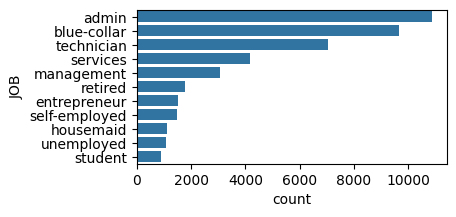

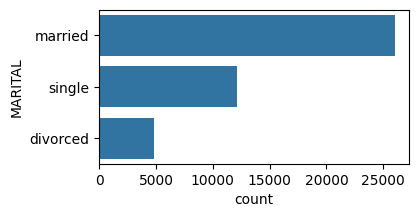

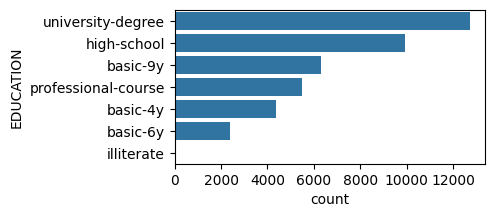

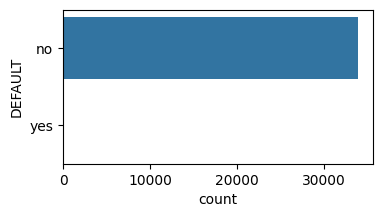

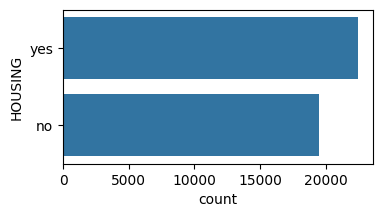

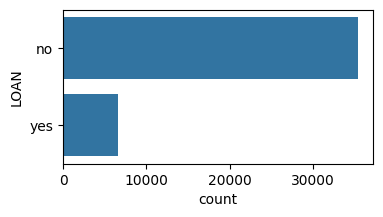

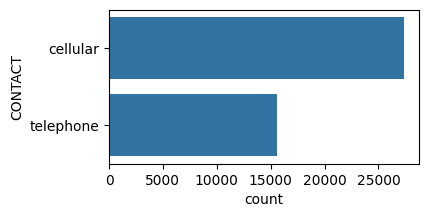

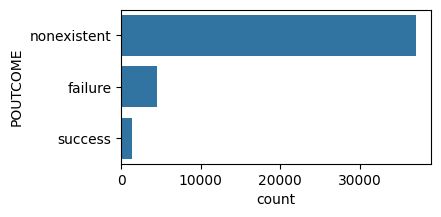

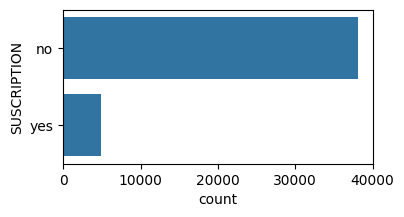

In [64]:
for col in df_bank_cat.columns:
    plt.figure(figsize=(4,2))

    sns.countplot(data=df_bank_cat, y=col, order=df_bank_cat[col].value_counts().index)

    plt.show()